#Estimation of Obesity Levels Based On Eating Habits and Physical Condition Data Visualization


The objective of this analysis is to explore the relationship between lifestyle behaviors and obesity levels using the dataset.  
We aim to identify key patterns and insights that can help explain factors contributing to obesity.

In [1]:
import pandas as pd

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print(df.head())

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

The dataset contains demographic and behavioral information such as:
- Gender, Age
- Height and Weight
- Eating habits (e.g., fast food consumption)
- Physical activity level (FAF)
- Water intake (CH2O)
- Obesity level classification (NObeyesdad)

The target variable is **NObeyesdad**, which represents different levels of obesity.


###  Distribution of Obesity Levels
This visualization shows the number of individuals in each obesity category.

**Insight:**
- The dataset contains multiple obesity categories, including normal weight, overweight, and various obesity levels.
- If the distribution is uneven, it may indicate a class imbalance, which could affect further analysis or modeling.

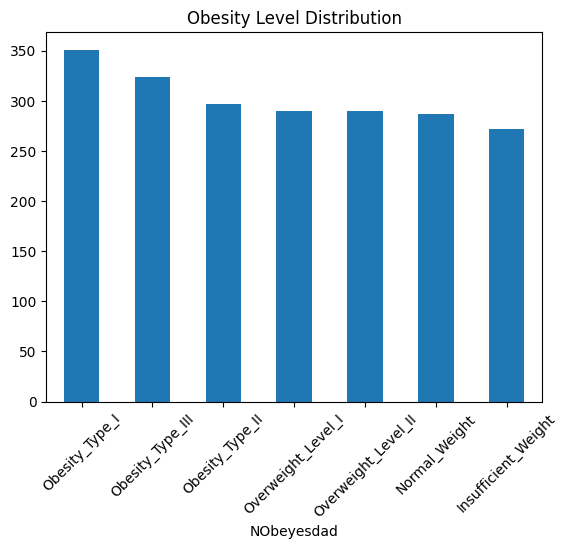

In [2]:
import matplotlib.pyplot as plt


df['NObeyesdad'].value_counts().plot(kind='bar')
plt.title('Obesity Level Distribution')
plt.xticks(rotation=45)
plt.show()

### Gender vs Obesity Level
This chart compares obesity levels across genders.

**Insight:**
- Differences between male and female distributions may suggest gender-related behavioral or biological factors.
- If one gender shows consistently higher obesity levels, this could indicate potential bias or real-world trends.

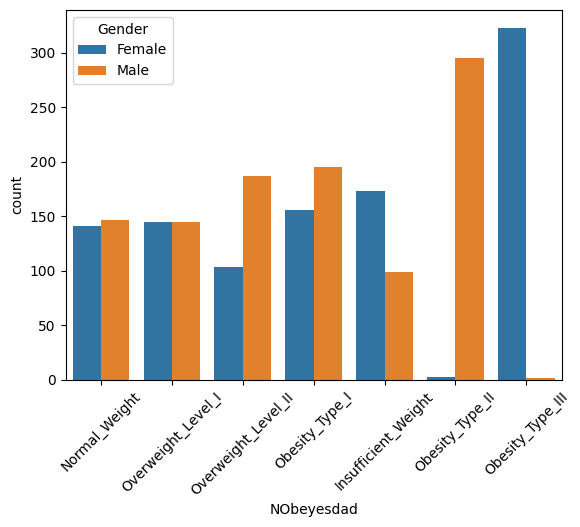

In [3]:
import seaborn as sns

sns.countplot(data=df, x='NObeyesdad', hue='Gender')
plt.xticks(rotation=45)
plt.show()

Height vs Weight (Correlation Analysis)
A scatter plot is used to visualize the relationship between height and weight, colored by obesity level.

**Insight:**
- Clear clustering can be observed, where individuals with higher weight tend to fall into higher obesity categories.
- Height has less variation compared to weight, suggesting weight is a stronger determinant of obesity classification.

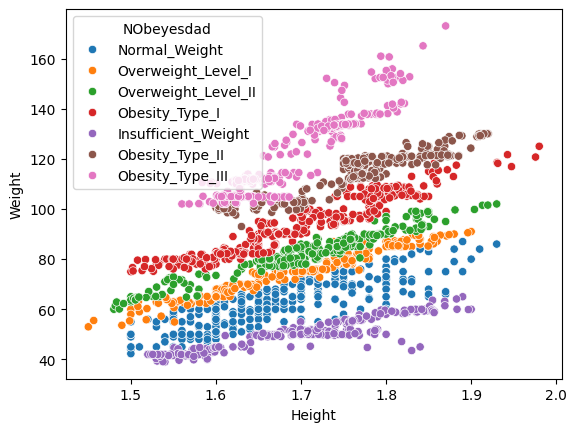

In [4]:
sns.scatterplot(data=df, x='Height', y='Weight', hue='NObeyesdad')
plt.show()

Physical Activity vs Obesity
A boxplot is used to analyze the relationship between physical activity frequency (FAF) and obesity level.

**Insight:**
- Individuals with lower physical activity levels tend to have higher obesity levels.
- This suggests that exercise plays a significant role in maintaining a healthy weight.

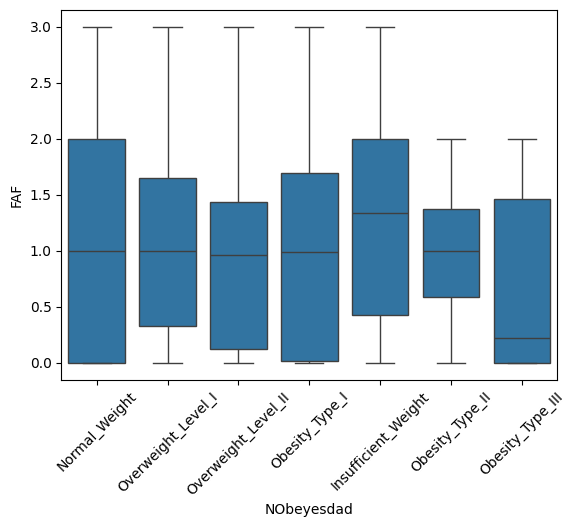

In [5]:
sns.boxplot(data=df, x='NObeyesdad', y='FAF')
plt.xticks(rotation=45)
plt.show()

### Fast Food Consumption vs Obesity
This visualization compares fast food consumption (FAVC) with obesity levels.

**Insight:**
- Individuals who frequently consume fast food show a higher tendency toward overweight and obesity.
- This supports the hypothesis that unhealthy eating habits contribute to obesity.


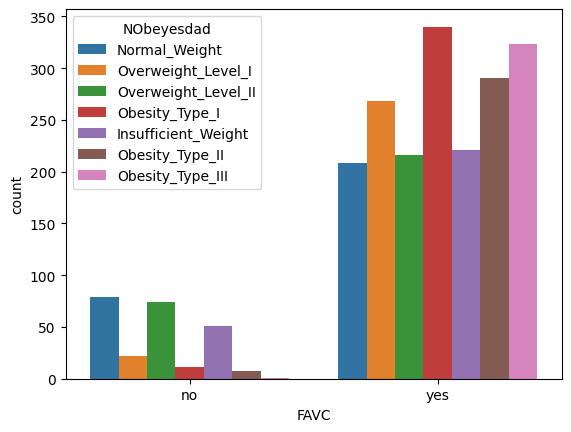

In [6]:
sns.countplot(data=df, x='FAVC', hue='NObeyesdad')
plt.show()

### Correlation Heatmap
A heatmap is used to identify relationships between numerical variables.

**Insight:**
- Weight shows strong correlation with obesity level.
- Lifestyle factors such as physical activity (FAF) and water intake (CH2O) may show weaker but meaningful relationships.
- These variables could be important for predicting or managing obesity.


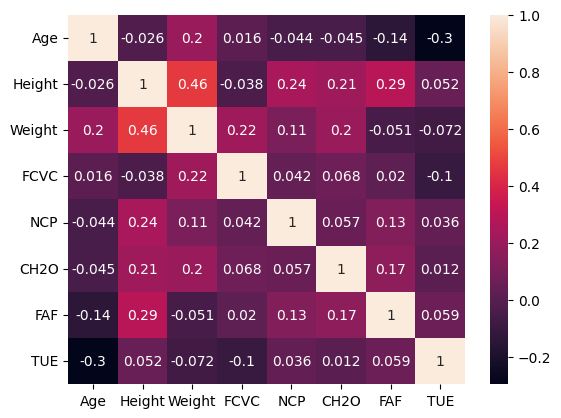

In [7]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.show()

In [8]:
import pandas as pd
df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
bins = [0, 25, 35, 100]
labels = ['Young', 'Adult', 'Older']

df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

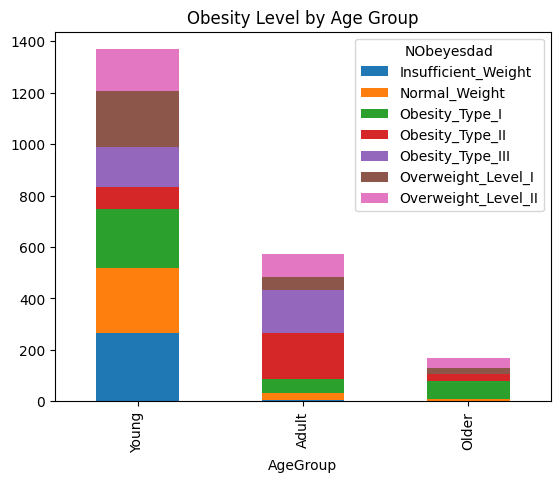

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

bins = [0, 25, 35, 100]
labels = ['Young', 'Adult', 'Older']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.groupby('AgeGroup', observed=True)['NObeyesdad'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title('Obesity Level by Age Group')
plt.show()

In [10]:
mapping = {
    'Insufficient_Weight': 'Underweight',
    'Normal_Weight': 'Normal',
    'Overweight_Level_I': 'Overweight',
    'Overweight_Level_II': 'Overweight',
    'Obesity_Type_I': 'Obese',
    'Obesity_Type_II': 'Obese',
    'Obesity_Type_III': 'Obese'
}

df['ObesityLevel'] = df['NObeyesdad'].map(mapping)

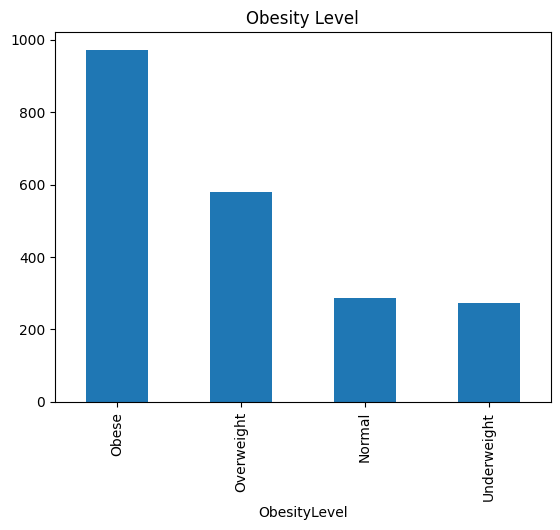

In [11]:
df['ObesityLevel'].value_counts().plot(kind='bar')
plt.title('Obesity Level')
plt.show()

#Vegetable Consumption

In [12]:
bins = [0, 2, 3, 4]
labels = ['Low Veg', 'Medium Veg', 'High Veg']

df['VegGroup'] = pd.cut(df['FCVC'], bins=bins, labels=labels)

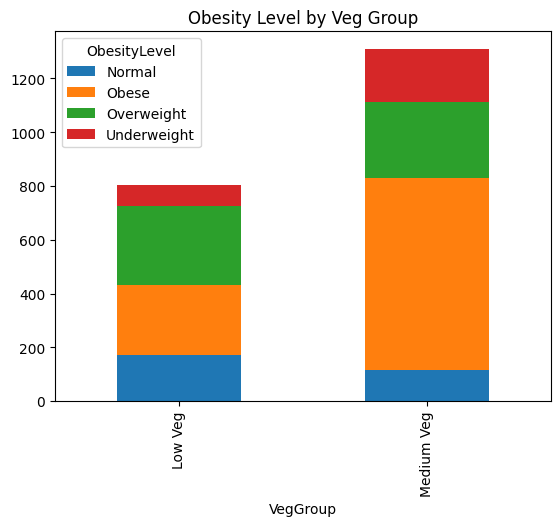

In [13]:
pd.crosstab(df['VegGroup'], df['ObesityLevel']).plot(kind='bar', stacked=True)
plt.title('Obesity Level by Veg Group')
plt.show()

In [14]:
bins = [0, 1, 3, 7]
labels = ['Low', 'Medium', 'High']

df['ActivityLevel'] = pd.cut(df['FAF'], bins=bins, labels=labels)

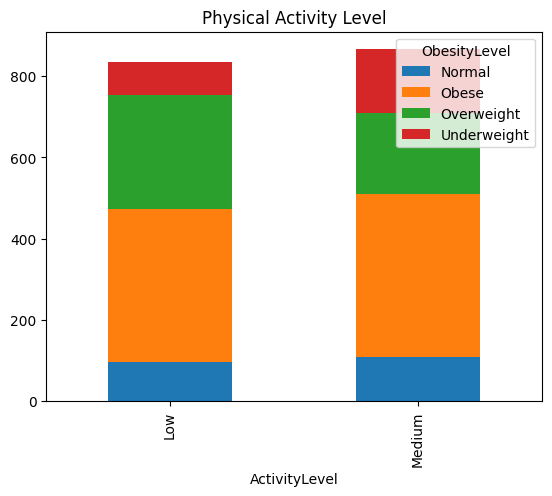

In [15]:
pd.crosstab(df['ActivityLevel'], df['ObesityLevel']).plot(kind='bar', stacked=True)
plt.title('Physical Activity Level')
plt.show()

#Lifestyle Region

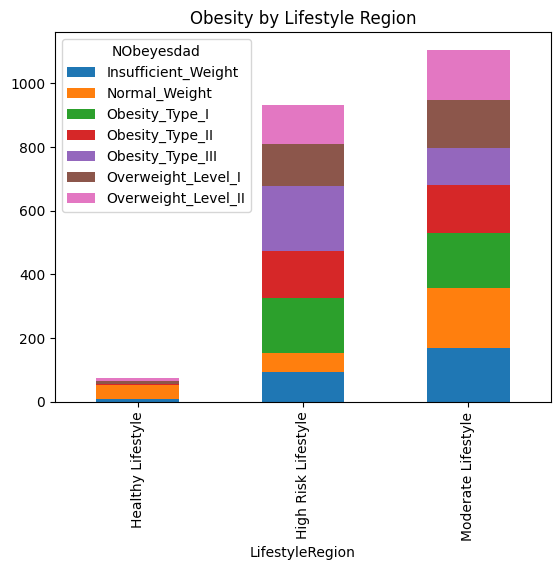

In [16]:
def lifestyle_region(row):
    if row['FAF'] >= 2 and row['FAVC'] == 'no':
        return 'Healthy Lifestyle'
    elif row['FAF'] < 1 and row['FAVC'] == 'yes':
        return 'High Risk Lifestyle'
    else:
        return 'Moderate Lifestyle'

df['LifestyleRegion'] = df.apply(lifestyle_region, axis=1)


region_group = df.groupby('LifestyleRegion')['NObeyesdad'].value_counts().unstack()

region_group.plot(kind='bar', stacked=True, title='Obesity by Lifestyle Region')
plt.show()

#Population Region

C:\Users\iceberg\AppData\Local\Temp\ipykernel_19072\3773049025.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group = df.groupby('AgeGroup')['NObeyesdad'].value_counts().unstack()


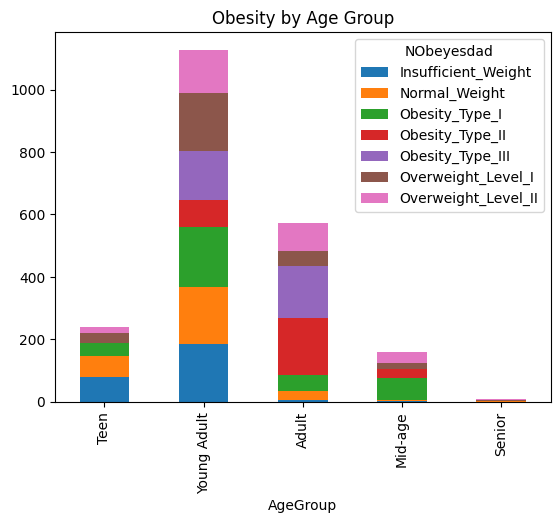

In [17]:
df['AgeGroup'] = pd.cut(df['Age'],
                       bins=[0, 18, 25, 35, 50, 100],
                       labels=['Teen', 'Young Adult', 'Adult', 'Mid-age', 'Senior'])

age_group = df.groupby('AgeGroup')['NObeyesdad'].value_counts().unstack()

age_group.plot(kind='bar', stacked=True, title='Obesity by Age Group')
plt.show()

#Mobility Regions (transportation behavior)


In [18]:
def transport_type(x):
    if x in ['Walking', 'Bike']:
        return 'Active'
    else:
        return 'Passive'

df['TransportGroup'] = df['MTRANS'].apply(transport_type)

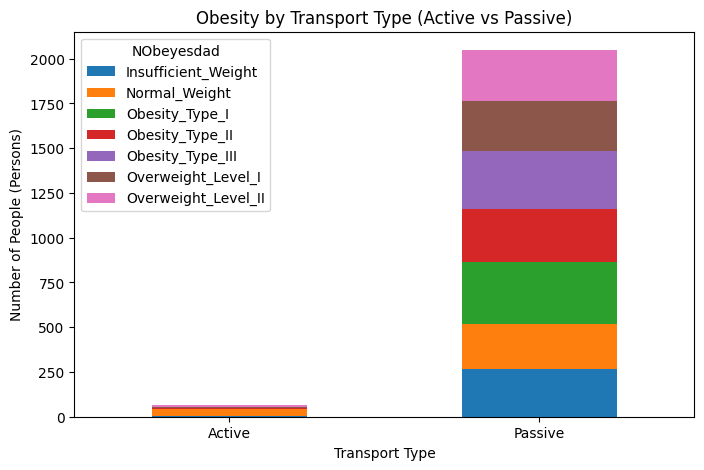

In [19]:
group = df.groupby('TransportGroup')['NObeyesdad'].value_counts().unstack()

group.plot(kind='bar', stacked=True, figsize=(8,5), title='Obesity by Transport Type (Active vs Passive)')
plt.xlabel('Transport Type')
plt.ylabel('Number of People (Persons)')
plt.xticks(rotation=0)
plt.show()

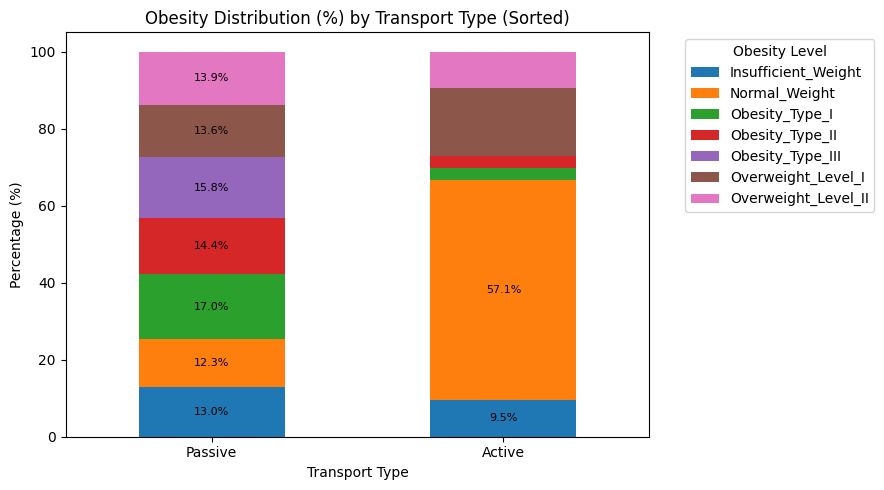

In [20]:
import matplotlib.pyplot as plt

# 1. Active / Passive
def transport_type(x):
    if x in ['Walking', 'Bike']:
        return 'Active'
    else:
        return 'Passive'

df['TransportGroup'] = df['MTRANS'].apply(transport_type)

# 2. group → %
group = df.groupby('TransportGroup')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# 3. Select column representing "Obese"
# (Usually 'Obesity_Type_III' in this dataset)
obesity_col = 'Obesity_Type_III'

# 4. Sort from min → max
group_pct = group_pct.sort_values(by=obesity_col)

# 5. plot
ax = group_pct.plot(kind='bar', stacked=True, figsize=(9,5))

plt.title('Obesity Distribution (%) by Transport Type (Sorted)')
plt.xlabel('Transport Type')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# 6. Add % on the chart
for i in range(len(group_pct)):
    cumulative = 0
    for j in range(len(group_pct.columns)):
        value = group_pct.iloc[i, j]
        if value > 5:
            ax.text(i, cumulative + value/2, f"{value:.1f}%", ha='center', va='center', fontsize=8)
        cumulative += value

plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

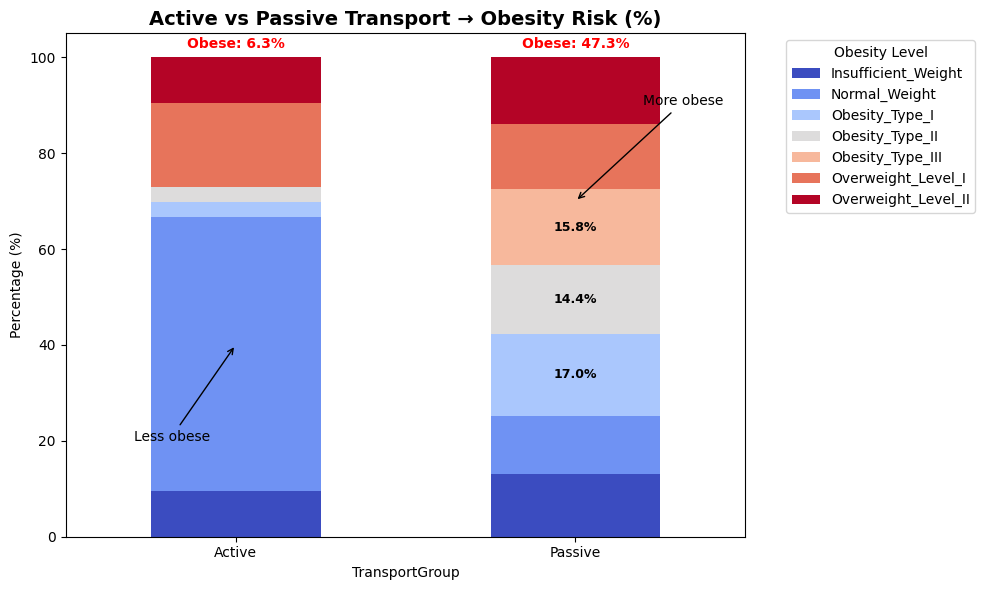

In [21]:


# create Active / Passive
def transport_type(x):
    return 'Active' if x in ['Walking', 'Bike'] else 'Passive'

df['TransportGroup'] = df['MTRANS'].apply(transport_type)

# group → %
group = df.groupby('TransportGroup')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# total obesity %
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

# sort by obesity
group_pct = group_pct.loc[total_obesity.sort_values().index]

# plot
ax = group_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')

plt.title('Active vs Passive Transport → Obesity Risk (%)', fontsize=14, weight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# label obesity %
for i in range(len(group_pct)):
    cumulative = 0
    for col in group_pct.columns:
        value = group_pct.iloc[i][col]
        if col in obesity_cols and value > 5:
            ax.text(i, cumulative + value/2, f"{value:.1f}%",
                    ha='center', va='center', fontsize=9, weight='bold')
        cumulative += value

# show total obesity on top
for i, val in enumerate(total_obesity.sort_values()):
    ax.text(i, 102, f"Obese: {val:.1f}%", ha='center', fontsize=10, color='red', weight='bold')

# simple annotation
plt.annotate("More obese", xy=(1, 70), xytext=(1.2, 90),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Less obese", xy=(0, 40), xytext=(-0.3, 20),
             arrowprops=dict(arrowstyle="->"))

plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

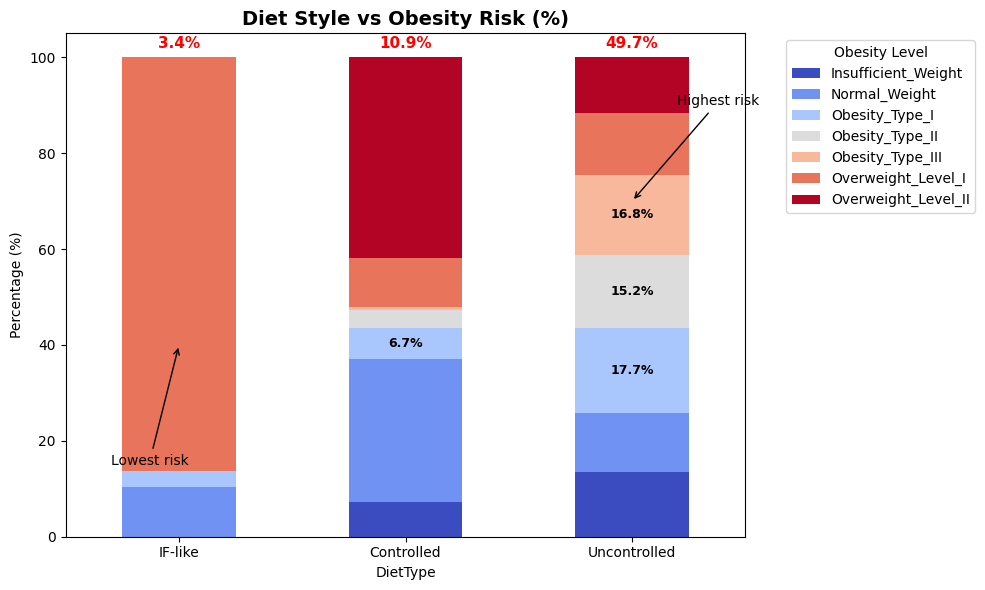

In [22]:
import matplotlib.pyplot as plt

#define diet styles
def diet_type(row):
    if row['NCP'] <= 2 and row['CAEC'] == 'no':
        return 'IF-like'
    elif row['FAVC'] == 'no' and row['CAEC'] in ['Sometimes', 'no']:
        return 'Controlled'
    else:
        return 'Uncontrolled'

df['DietType'] = df.apply(diet_type, axis=1)

# 2. group as %
group = df.groupby('DietType')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# 3. total obesity (main insight)
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

#sort (low → high risk)
group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

ax = group_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='coolwarm'
)

plt.title('Diet Style vs Obesity Risk (%)', fontsize=14, weight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# highlight ONLY obesity
for i in range(len(group_pct)):
    cumulative = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(i, cumulative + val/2,
                    f"{val:.1f}%",
                    ha='center', va='center',
                    fontsize=9, weight='bold', color='black')
        cumulative += val

for i, val in enumerate(total_obesity):
    ax.text(i, 102, f"{val:.1f}%",
            ha='center', fontsize=11,
            color='red', weight='bold')

plt.annotate("Lowest risk", xy=(0, 40), xytext=(-0.3, 15),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Highest risk", xy=(2, 70), xytext=(2.2, 90),
             arrowprops=dict(arrowstyle="->"))

plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#Seasoning Behavior

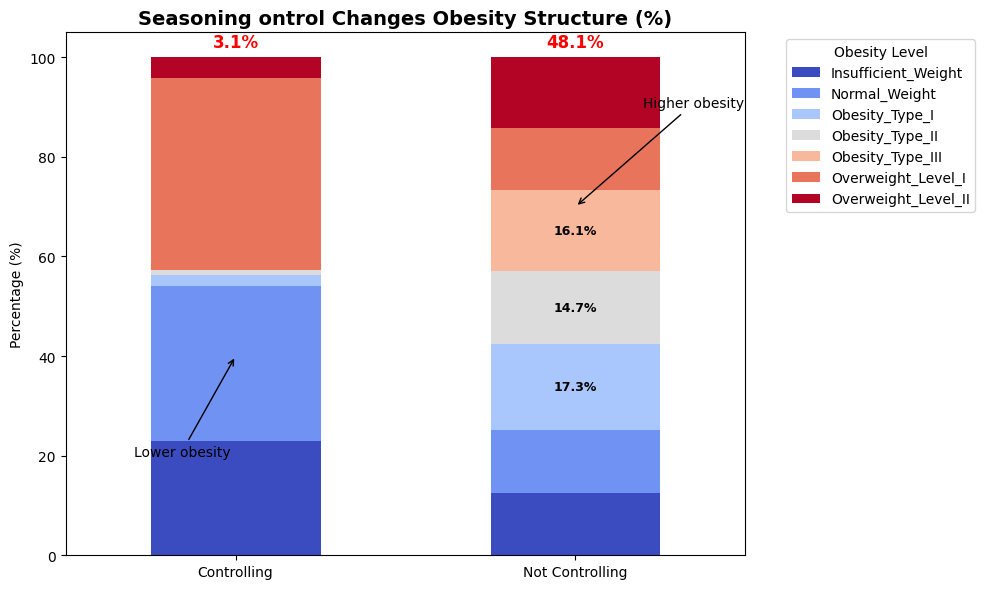

In [23]:
import matplotlib.pyplot as plt

# group %
group = df.groupby('SCC')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

group_pct.index = ['Not Controlling', 'Controlling']

# total obesity (main insight)
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

# sort
group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

# plot
ax = group_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')

plt.title('Seasoning ontrol Changes Obesity Structure (%)', fontsize=14, weight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

# highlight obesity
for i in range(len(group_pct)):
    cum = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(i, cum + val/2, f"{val:.1f}%", ha='center', va='center', fontsize=9, weight='bold')
        cum += val

# big number = takeaway
for i, val in enumerate(total_obesity):
    ax.text(i, 102, f"{val:.1f}%", ha='center', fontsize=12, color='red', weight='bold')

# storytelling arrows
plt.annotate("Higher obesity", xy=(1, 70), xytext=(1.2, 90),
             arrowprops=dict(arrowstyle="->"))

plt.annotate("Lower obesity", xy=(0, 40), xytext=(-0.3, 20),
             arrowprops=dict(arrowstyle="->"))

plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

#Screen times x Activity

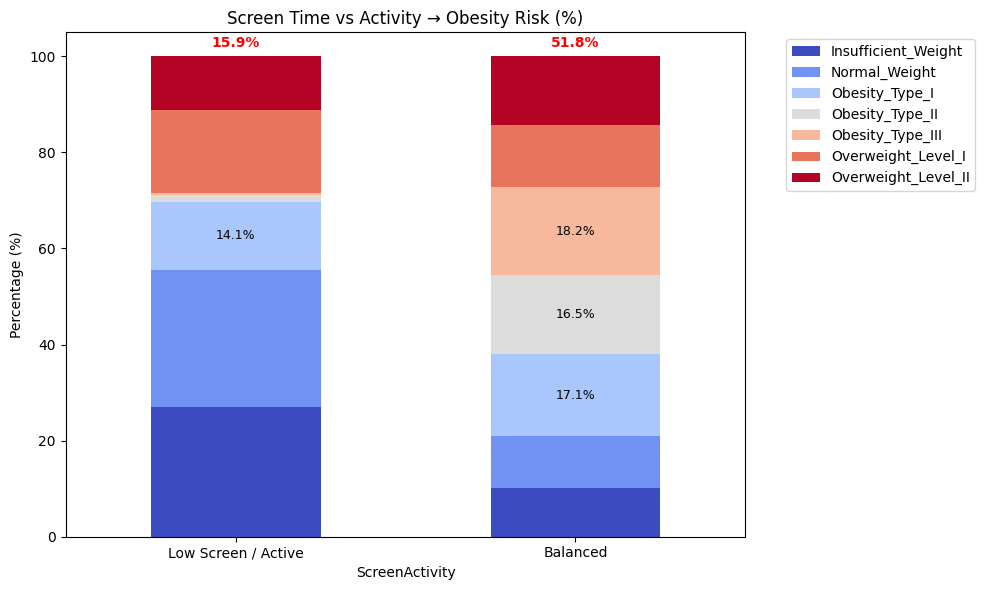

In [24]:
def screen_activity(row):
    if row['TUE'] > 3 and row['FAF'] < 1:
        return 'High Screen / Low Activity'
    elif row['TUE'] < 2 and row['FAF'] >= 2:
        return 'Low Screen / Active'
    else:
        return 'Balanced'

df['ScreenActivity'] = df.apply(screen_activity, axis=1)

group = df.groupby('ScreenActivity')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

ax = group_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')

plt.title('Screen Time vs Activity → Obesity Risk (%)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

for i in range(len(group_pct)):
    cum = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(i, cum + val/2, f"{val:.1f}%", ha='center', va='center', fontsize=9)
        cum += val

for i, val in enumerate(total_obesity):
    ax.text(i, 102, f"{val:.1f}%", ha='center', color='red', weight='bold')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

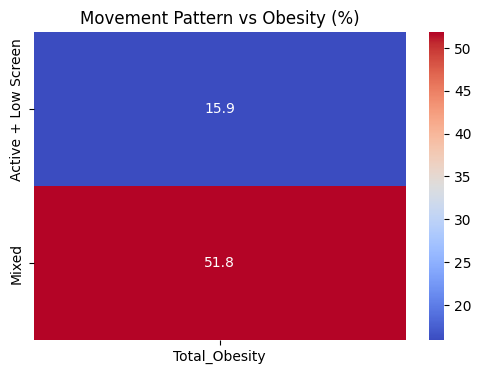

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

def movement_type(row):
    if row['FAF'] >= 2 and row['TUE'] < 2:
        return 'Active + Low Screen'
    elif row['FAF'] < 1 and row['TUE'] > 3:
        return 'Inactive + High Screen'
    else:
        return 'Mixed'

df['MovementType'] = df.apply(movement_type, axis=1)

# Calculate obesity % per group
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

group = df.groupby('MovementType')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

# Get total obesity
group_pct['Total_Obesity'] = group_pct[obesity_cols].sum(axis=1)

# Reshape for heatmap
heatmap_data = group_pct[['Total_Obesity']]

# plot
plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")

plt.title('Movement Pattern vs Obesity (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

#Family genetics x Lifestyle

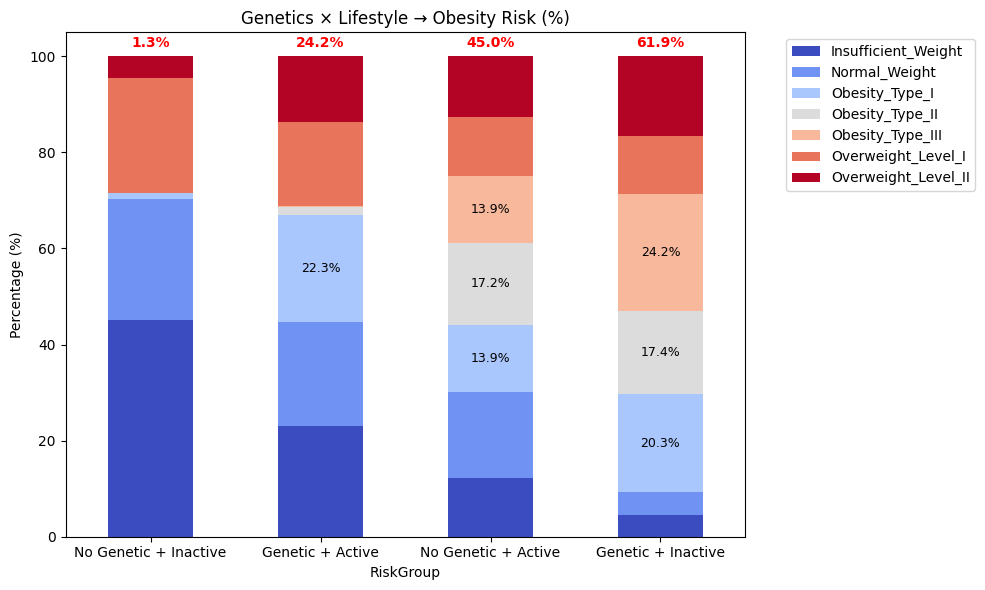

In [26]:
import matplotlib.pyplot as plt

def risk_group(row):
    if row['family_history_with_overweight'] == 'yes' and row['FAF'] < 1:
        return 'Genetic + Inactive'
    elif row['family_history_with_overweight'] == 'yes' and row['FAF'] >= 2:
        return 'Genetic + Active'
    elif row['family_history_with_overweight'] == 'no' and row['FAF'] < 1:
        return 'No Genetic + Inactive'
    else:
        return 'No Genetic + Active'

df['RiskGroup'] = df.apply(risk_group, axis=1)

group = df.groupby('RiskGroup')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
total_obesity = group_pct[obesity_cols].sum(axis=1)

# sort from low → high obesity
group_pct = group_pct.loc[total_obesity.sort_values().index]
total_obesity = total_obesity.sort_values()

ax = group_pct.plot(kind='bar', stacked=True, figsize=(10,6), colormap='coolwarm')

plt.title('Genetics × Lifestyle → Obesity Risk (%)')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)

for i in range(len(group_pct)):
    cum = 0
    for col in group_pct.columns:
        val = group_pct.iloc[i][col]
        if col in obesity_cols and val > 5:
            ax.text(i, cum + val/2, f"{val:.1f}%", ha='center', va='center', fontsize=9)
        cum += val

for i, val in enumerate(total_obesity):
    ax.text(i, 102, f"{val:.1f}%", ha='center', color='red', weight='bold')

plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

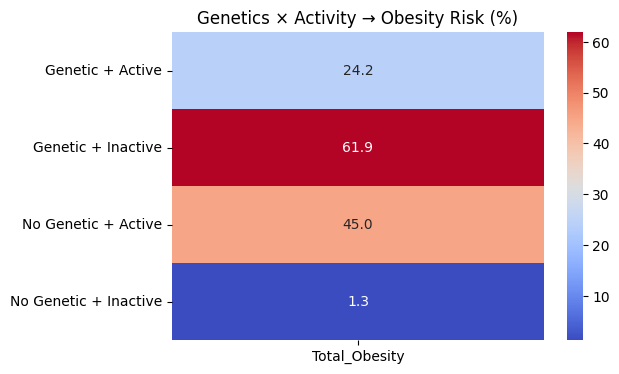

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

def risk_group(row):
    if row['family_history_with_overweight'] == 'yes' and row['FAF'] < 1:
        return 'Genetic + Inactive'
    elif row['family_history_with_overweight'] == 'yes' and row['FAF'] >= 2:
        return 'Genetic + Active'
    elif row['family_history_with_overweight'] == 'no' and row['FAF'] < 1:
        return 'No Genetic + Inactive'
    else:
        return 'No Genetic + Active'

df['RiskGroup'] = df.apply(risk_group, axis=1)

group = df.groupby('RiskGroup')['NObeyesdad'].value_counts().unstack()
group_pct = group.div(group.sum(axis=1), axis=0) * 100

obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']
group_pct['Total_Obesity'] = group_pct[obesity_cols].sum(axis=1)

heatmap_data = group_pct[['Total_Obesity']]

plt.figure(figsize=(6,4))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="coolwarm")

plt.title('Genetics × Activity → Obesity Risk (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

#Baby boomer generation's risk behaviors cause obesity

In [28]:
df_bb = df[df['Age'] >= 55].copy()
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,AgeGroup,ObesityLevel,VegGroup,ActivityLevel,LifestyleRegion,TransportGroup,DietType,ScreenActivity,MovementType,RiskGroup
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,...,Young Adult,Normal,Low Veg,NaN,Moderate Lifestyle,Passive,Controlled,Balanced,Mixed,Genetic + Inactive
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,...,Young Adult,Normal,Medium Veg,Medium,Healthy Lifestyle,Passive,Controlled,Low Screen / Active,Active + Low Screen,Genetic + Active
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,...,Young Adult,Normal,Low Veg,Medium,Healthy Lifestyle,Passive,Controlled,Low Screen / Active,Active + Low Screen,Genetic + Active
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,...,Adult,Overweight,Medium Veg,Medium,Healthy Lifestyle,Active,Controlled,Low Screen / Active,Active + Low Screen,No Genetic + Active
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,...,Young Adult,Overweight,Low Veg,NaN,Moderate Lifestyle,Passive,Controlled,Balanced,Mixed,No Genetic + Inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active


In [29]:
df_bb['High_Alcohol'] = df_bb['CALC'].isin(['Frequently', 'Always'])
df_bb['Low_Water'] = df_bb['CH2O'] < 2
df_bb['Snacking'] = df_bb['CAEC'].isin(['Frequently', 'Always'])
df_bb['Inactive'] = df_bb['FAF'] < 1
df_bb['High_Screen'] = df_bb['TUE'] > 3

In [30]:
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

results = {}

for col in ['High_Alcohol', 'Low_Water', 'Snacking', 'Inactive', 'High_Screen']:
    grp = df_bb.groupby(col)['NObeyesdad'].value_counts().unstack()
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100

    # Reindex grp_pct to ensure all obesity_cols are present, filling missing with 0
    # This handles cases where certain obesity types might not exist for a given group
    grp_pct_reindexed = grp_pct.reindex(columns=grp_pct.columns.union(obesity_cols), fill_value=0)
    grp_pct['Total_Obesity'] = grp_pct_reindexed[obesity_cols].sum(axis=1)

    if True in grp_pct.index:
        results[col] = grp_pct.loc[True, 'Total_Obesity']

import pandas as pd
risk_df_bb = pd.DataFrame.from_dict(results, orient='index', columns=['Obesity_%'])
risk_df_bb = risk_df_bb.sort_values(by='Obesity_%')

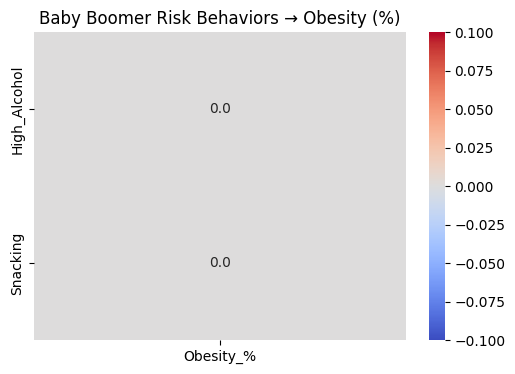

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(risk_df_bb, annot=True, fmt=".1f", cmap="coolwarm")

plt.title('Baby Boomer Risk Behaviors → Obesity (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

#Genz risk behaviors cause obesity

In [32]:
df_genz = df[df['Age'] <= 25].copy()
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,...,AgeGroup,ObesityLevel,VegGroup,ActivityLevel,LifestyleRegion,TransportGroup,DietType,ScreenActivity,MovementType,RiskGroup
0,Female,21.000000,1.620000,64.000000,yes,no,2.0,3.0,Sometimes,no,...,Young Adult,Normal,Low Veg,NaN,Moderate Lifestyle,Passive,Controlled,Balanced,Mixed,Genetic + Inactive
1,Female,21.000000,1.520000,56.000000,yes,no,3.0,3.0,Sometimes,yes,...,Young Adult,Normal,Medium Veg,Medium,Healthy Lifestyle,Passive,Controlled,Low Screen / Active,Active + Low Screen,Genetic + Active
2,Male,23.000000,1.800000,77.000000,yes,no,2.0,3.0,Sometimes,no,...,Young Adult,Normal,Low Veg,Medium,Healthy Lifestyle,Passive,Controlled,Low Screen / Active,Active + Low Screen,Genetic + Active
3,Male,27.000000,1.800000,87.000000,no,no,3.0,3.0,Sometimes,no,...,Adult,Overweight,Medium Veg,Medium,Healthy Lifestyle,Active,Controlled,Low Screen / Active,Active + Low Screen,No Genetic + Active
4,Male,22.000000,1.780000,89.800000,no,no,2.0,1.0,Sometimes,no,...,Young Adult,Overweight,Low Veg,NaN,Moderate Lifestyle,Passive,Controlled,Balanced,Mixed,No Genetic + Inactive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,...,Young Adult,Obese,Medium Veg,Medium,Moderate Lifestyle,Passive,Uncontrolled,Balanced,Mixed,No Genetic + Active


In [33]:
df_genz['High_Alcohol'] = df_genz['CALC'].isin(['Frequently', 'Always'])
df_genz['Low_Water'] = df_genz['CH2O'] < 2
df_genz['Snacking'] = df_genz['CAEC'].isin(['Frequently', 'Always'])
df_genz['Inactive'] = df_genz['FAF'] < 1
df_genz['High_Screen'] = df_genz['TUE'] > 3

In [34]:
obesity_cols = ['Obesity_Type_I', 'Obesity_Type_II', 'Obesity_Type_III']

results = {}

for col in ['High_Alcohol', 'Low_Water', 'Snacking', 'Inactive', 'High_Screen']:
    grp = df_genz.groupby(col)['NObeyesdad'].value_counts().unstack()
    grp_pct = grp.div(grp.sum(axis=1), axis=0) * 100
    grp_pct['Total_Obesity'] = grp_pct[obesity_cols].sum(axis=1)

    # Only add to results if the 'True' category (risky behavior) exists in the index
    if True in grp_pct.index:
        results[col] = grp_pct.loc[True, 'Total_Obesity']

import pandas as pd
risk_df = pd.DataFrame.from_dict(results, orient='index', columns=['Obesity_%'])
risk_df = risk_df.sort_values(by='Obesity_%')

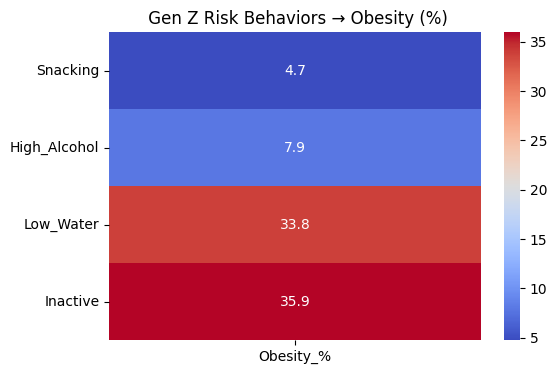

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(risk_df, annot=True, fmt=".1f", cmap="coolwarm")

plt.title(' Gen Z Risk Behaviors → Obesity (%)')
plt.ylabel('')
plt.xlabel('')
plt.show()

### Eating Between Meals vs Obesity

Analyze the relationship between snacking habits (CAEC) and obesity levels (NObeyesdad).

---

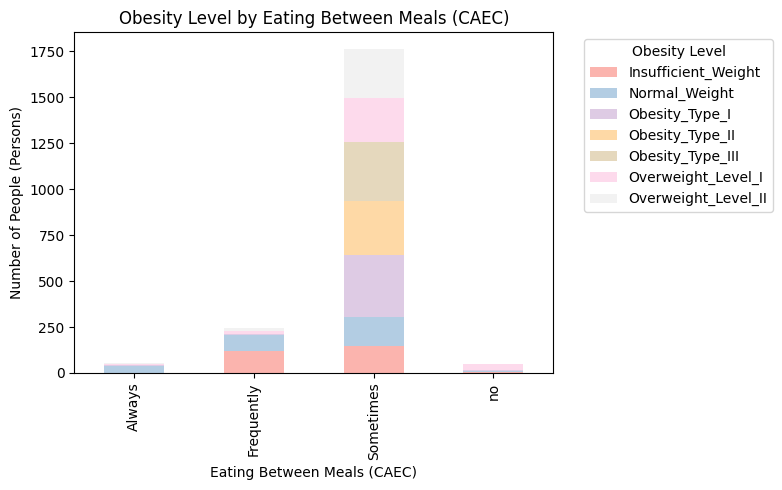

In [38]:
# Bar plot: Eating Between Meals vs Obesity Level
eat_group = df.groupby(['CAEC', 'NObeyesdad']).size().unstack()
eat_group.plot(kind='bar', stacked=True, figsize=(8,5), colormap='Pastel1')
plt.title('Obesity Level by Eating Between Meals (CAEC)')
plt.xlabel('Eating Between Meals (CAEC)')
plt.ylabel('Number of People (Persons)')
plt.legend(title='Obesity Level', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 1. The Digital Addict: Screen Time vs. Physical Activity
Analyze 'Screen Time' (TUE) vs 'Physical Activity' (FAF) using Plotly for a premium, interactive experience.

In [43]:
import plotly.express as px

# 1. The Digital Addict: Screen Time vs. Physical Activity (Simplified Heatmap)
# Using a Density Heatmap with text annotations (text_auto) for immediate clarity.
fig1 = px.density_heatmap(df, 
                         x="TUE", 
                         y="FAF", 
                         title="Digital Addict: Correlation Between Screen Time & Activity",
                         labels={"count": "Number of People", "TUE": "Screen Time (Hours/Day)", "FAF": "Activity Frequency (Days/Week)"},
                         template="plotly_dark",
                         color_continuous_scale="Viridis",
                         text_auto=True) # Displays count in each bin for clarity

fig1.update_layout(
    font_family="Inter",
    title_x=0.5,
    title_font_size=24,
    xaxis_title="Screen Time (Hours/Day)",
    yaxis_title="Activity Frequency (Days/Week)"
)

fig1.show()

In [ ]:
import plotly.express as px

# 1.1. Digital Addict vs. Obesity Levels (Faceted Heatmap - Simplified)
df_facets = df.copy()

def simplify_obesity(status):
    if 'Obesity' in status or 'Overweight' in status:
        return 'Overweight / Obese'
    else:
        return 'Normal / Underweight'

df_facets['Status_Group'] = df_facets['NObeyesdad'].apply(simplify_obesity)

fig1_1 = px.density_heatmap(df_facets, 
                           x="TUE", 
                           y="FAF", 
                           facet_col="Status_Group",
                           title="Behavioral Shift: Normal Weight vs. Overweight Groups",
                           labels={
                               "TUE": "Screen Time (Hours/Day)", 
                               "FAF": "Activity Frequency (Days/Week)",
                               "Status_Group": "Health Status"
                           },
                           template="plotly_dark",
                           color_continuous_scale="Viridis",
                           text_auto=True)

fig1_1.update_layout(
    font_family="Inter",
    title_x=0.5,
    title_font_size=24,
    xaxis_title="Screen Time Level",
    yaxis_title="Activity Level"
)

fig1_1.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))

fig1_1.show()

## 2. The Lazy Commuter: Transport Mode vs. Activity
Examine how transportation modes (MTRANS) affect physical activity and sedentary levels.

In [46]:
# Analyze the relationship between transportation mode and movement frequency.
fig2 = px.box(df, 
             x="MTRANS", 
             y="FAF", 
             color="MTRANS",
             points="all",
             template="plotly_white",
             title="Lazy Commuter: How Transport Mode Affects Movement",
             color_discrete_sequence=px.colors.sequential.Tealgrn)

fig2.update_layout(
    xaxis_title="Mode of Transportation",
    yaxis_title="Activity Frequency (Days/Week)",
    showlegend=False
)

fig2.show()

## 3. Liquid Sins: Alcohol Consumption vs. Water Intake
Explore whether frequent alcohol consumers (CALC) maintain adequate daily water intake (CH2O).

In [ ]:
import plotly.graph_objects as go
import numpy as np

# 3. Liquid Sins: Alcohol vs. Water Intake (Upgraded to Ridgeline Plot)
categories = ['no', 'Sometimes', 'Frequently', 'Always']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c'] # Green to Red palette

fig3 = go.Figure()

for cat, color in zip(categories, colors):
    df_cat = df[df['CALC'] == cat]
    fig3.add_trace(go.Violin(
        x=df_cat['CH2O'],
        line_color=color,
        name=cat,
        orientation='h',
        side='positive',
        width=3,
        points=False,
        meanline_visible=True
    ))

fig3.update_layout(
    title="Liquid Sins: Ridgeline Distribution of Water Intake by Alcohol Consumption",
    xaxis_title="Water Intake (Liters/Day)",
    yaxis_title="Alcohol Frequency",
    template="plotly_dark",
    font_family="Inter",
    title_x=0.5,
    title_font_size=24,
    violingap=0,
    violingroupgap=0,
    violinmode='overlay',
    showlegend=False
)

fig3.update_yaxes(categoryorder='array', categoryarray=categories)

fig3.show()

## 4. Snacking Addict: Eating Between Meals
Analyze snacking habits (CAEC) as a primary factor in lifestyle-related behaviors.

In [42]:
# Create a Sunburst Chart to view snacking proportions across age groups.
fig4 = px.sunburst(df, 
                  path=['AgeGroup', 'CAEC'], 
                  values='Age',
                  title="Snacking Hierarchy: Habits by Age Group",
                  color='CAEC',
                  color_discrete_map={'(?)':'black', 'Sometimes':'gold', 'Frequently':'crimson', 'Always':'darkred', 'no':'seagreen'},
                  template="presentation")

fig4.update_layout(title_font_size=22)
fig4.show()